In [1]:
#0.Warm-up: use Monte-carlo simulation (which simulates the risk-neutral world) to calculate pi.

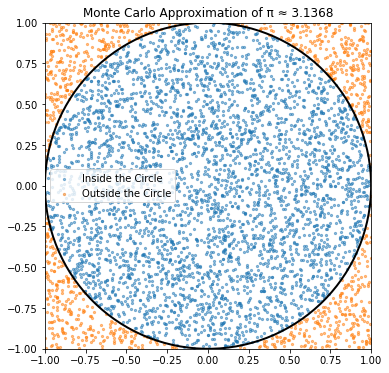

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Number of random points
N = 5000

# Set random x and y coordinates
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Check whether points are inside the circle
inside = x**2 + y**2 <= 1

# Count points inside the circle
count = np.sum(inside)

# Approximate pi
hat_pi = 4 * count / N

fig, ax = plt.subplots(figsize = (6,6))

# Points inside the circle
ax.scatter(x[inside], y[inside], s = 5, alpha = 0.5, label = 'Inside the Circle')

# Points outside the circle
ax.scatter(x[~inside], y[~inside], s = 5, alpha = 0.5, label = 'Outside the Circle')

# Plot the circle
circle = plt.Circle((0, 0), 1, fill = False, color = 'black', linewidth = 2)
ax.add_patch(circle)

# Plot the square boundaries
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# Make aspect ratio equal
ax.set_aspect('equal')

ax.set_title(f"Monte Carlo Approximation of π ≈ {hat_pi}")

ax.legend()

plt.show()

In [7]:
#1.Portfolio Optimisation. The covariance of two assets is defined by:

In [9]:
from IPython.display import display, Math

display(Math(
    r"\mathrm{Cov}(R_A, R_B) = "
    r"\frac{\sum_{i=1}^{n}(R_{Ai}-\overline{R_A})(R_{Bi}-\overline{R_B})}{n-1}."
))

<IPython.core.display.Math object>

In [ ]:
# Here R_Ai and R_Bi are the net returns of assets A and B in the ith interval, while R_A and R_B are the means of
# the returns of assets A and B, and n is the sample size or the number of intervals.

In [13]:
import numpy as np
from scipy.stats import norm

# Expected returns and covariance matrix of asset returns
R = np.array([0.14, 0.11, 0.20])
Sigma = np.array([
    [0.09, 0.07, 0.10],
    [0.08, 0.03, 0.06],
    [0.07, 0.05, 0.04]
])

# Portfolio weights
w = np.array([0.3, 0.5, 0.2])

# Expected portfolio return
mu_p = np.dot(w, R)

# Expected portfolio variance
sigma2_p = np.dot(w.T, np.dot(Sigma, w))

# Expected portfolio standard deviation (volatility)
sigma_p = np.sqrt(sigma2_p)

# Confidence level
alpha = 0.95

# Z-score for the left tail
z = norm.ppf(1 - alpha)

# Value-at-Risk
VaR = -z * sigma_p - mu_p

# Expected shortfall
ES = -mu_p + sigma_p * norm.pdf(z) / (1 - alpha)

print(f"Expected Portfolio Return: {mu_p:.2f}")
print(f"Expected Portfolio Volatility: {sigma_p:.2f}")
print(f"95% VaR: {VaR:.2f}")
print(f"Expected Shortfall: {ES:.2f}")

Expected Portfolio Return: 0.14
Expected Portfolio Volatility: 0.25
95% VaR: 0.27
Expected Shortfall: 0.37
